In [1]:
import numpy as np
import pandas as pd
import uproot
from pathlib import Path
from glob import glob
import re

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mutools.plotting import use_style
from mutools.plotting.helpers import mark_axis

use_style('rootlike')

INPUT = Path('/Users/mueller/Projects/spineosc/parameter_scan')

In [2]:
pattern = re.compile(r"dmsq([-\d.eE+]+)_sinsq([-\d.eE+]+)_grid(\d+)_PROplot\.root$")

# Oscillation in the parameter scan

A first look at the injected grid points in `INPUT`: what a scan file holds,
how an oscillated spectrum differs from the unoscillated CV, and how the rate
deficit moves across the $(\sin^2 2\theta,\ \Delta m^2)$ grid.

In [3]:
# Names as they appear in the scan files. Each subchannel also has a matching
# *slc histogram, but those are all empty here, so these six are the whole
# prediction. 'nu' is the mode and '_numu' is part of the channel name.
DETECTORS = ('SBND', 'ICARUS')
CHANNELS = ('ccqelike', 'nproton')
SUBCHANNELS = ('cos', 'intime', 'nc', 'nuecc', 'nuothercc', 'nutarget')

# Fixed series order, checked for colourblind separation.
SERIES_COLORS = ('#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7')

rows = []
for path in sorted(INPUT.glob('*_PROplot.root')):
    match = pattern.search(path.name)
    if match is None:
        continue
    rows.append({'dmsq': float(match.group(1)), 'sinsq': float(match.group(2)),
                 'grid': int(match.group(3)), 'path': path})

scan = pd.DataFrame(rows).sort_values(['dmsq', 'sinsq'], ignore_index=True)

print(f'{len(scan)} grid points: '
      f'{scan.dmsq.nunique()} dmsq x {scan.sinsq.nunique()} sinsq')
print(f'  dmsq  {scan.dmsq.min():g} to {scan.dmsq.max():g} eV^2')
print(f'  sinsq {scan.sinsq.min():g} to {scan.sinsq.max():g}')
scan.head()

900 grid points: 30 dmsq x 30 sinsq
  dmsq  0.1 to 100 eV^2
  sinsq 0.1 to 1


,dmsq,sinsq,grid,path
0,0.1,0.100000,0,/Users/mueller/Projects/spineosc/parameter_sca...
1,0.1,0.108264,1,/Users/mueller/Projects/spineosc/parameter_sca...
2,0.1,0.117210,2,/Users/mueller/Projects/spineosc/parameter_sca...
3,0.1,0.126896,3,/Users/mueller/Projects/spineosc/parameter_sca...
4,0.1,0.137382,4,/Users/mueller/Projects/spineosc/parameter_sca...


## What one scan file holds

`Osc_hists/` is the oscillated prediction at that grid point, split by
subchannel. `ErrorBand/Var0/..._cv1d` is the unoscillated CV - it is byte
identical in all 900 files, so it serves as the common baseline.

In [4]:
def oscillated(f, detector, channel):
    """Oscillated spectrum at this grid point: the subchannels, summed."""
    total = None
    for sub in SUBCHANNELS:
        hist = f[f'Osc_hists/nu_{detector}_{channel}_numu_{sub}']
        total = hist.values() if total is None else total + hist.values()
    return hist.axis().edges(), total


def unoscillated(f, detector, channel):
    """The no-oscillation CV spectrum, the same in every grid file."""
    hist = f[f'ErrorBand/Var0/nu_{detector}_{channel}_numu_cv1d']
    return hist.axis().edges(), hist.values()


with uproot.open(scan.path.iloc[0]) as f:
    for detector in DETECTORS:
        for channel in CHANNELS:
            edges, cv = unoscillated(f, detector, channel)
            osc = oscillated(f, detector, channel)[1]
            print(f'{detector:7s} {channel:9s} {len(cv):2d} bins  '
                  f'{edges[0]:.2f}-{edges[-1]:.2f} GeV  '
                  f'{cv.sum():7.1f} unosc  {osc.sum():7.1f} osc')

SBND    ccqelike  16 bins  0.30-1.50 GeV   4235.7 unosc   4235.6 osc
SBND    nproton   14 bins  0.40-2.00 GeV   1290.5 unosc   1290.5 osc
ICARUS  ccqelike  16 bins  0.30-1.50 GeV   1874.3 unosc   1872.5 osc
ICARUS  nproton   14 bins  0.40-2.00 GeV    692.9 unosc    692.5 osc


In [5]:
# Load the whole grid: ~8 s, ~900 files.
cv_ref, osc_spectra = {}, {}

with uproot.open(scan.path.iloc[0]) as f:
    for detector in DETECTORS:
        for channel in CHANNELS:
            cv_ref[detector, channel] = unoscillated(f, detector, channel)
            osc_spectra[detector, channel] = np.zeros(
                (len(scan), len(cv_ref[detector, channel][1])))

for i, path in enumerate(scan.path):
    with uproot.open(path) as f:
        for detector in DETECTORS:
            for channel in CHANNELS:
                osc_spectra[detector, channel][i] = oscillated(f, detector, channel)[1]

# Oscillated / unoscillated total rate, one number per grid point.
osc_rates = {key: spectra.sum(axis=1) / cv_ref[key][1].sum()
             for key, spectra in osc_spectra.items()}

print('loaded', {k: v.shape for k, v in osc_spectra.items()})

loaded {('SBND', 'ccqelike'): (900, 16), ('SBND', 'nproton'): (900, 14), ('ICARUS', 'ccqelike'): (900, 16), ('ICARUS', 'nproton'): (900, 14)}


## Spectra at a few grid points

Maximal mixing, four $\Delta m^2$ values. SBND (110 m) and ICARUS (600 m) see
the same oscillation at different L/E, so the same $\Delta m^2$ does very
different things to the two spectra.

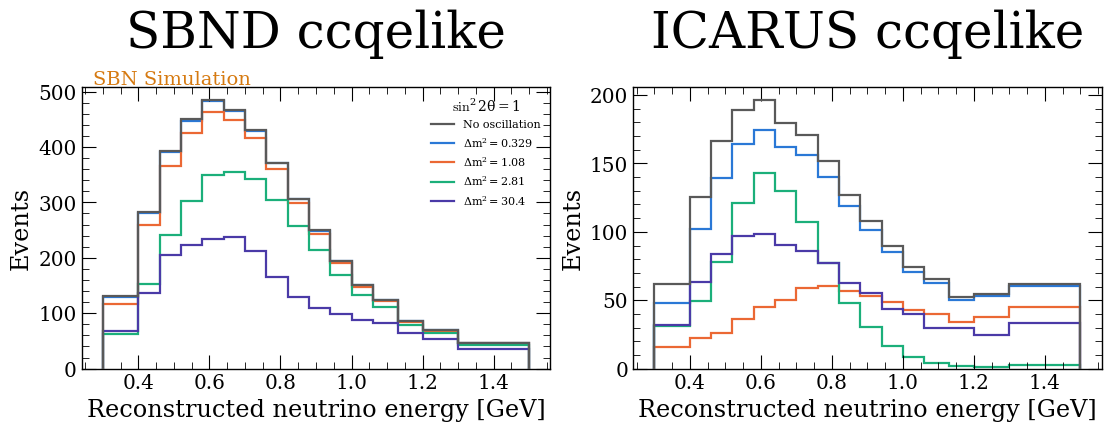

In [6]:
CHANNEL = 'ccqelike'
SINSQ = scan.sinsq.max()

# Grid points nearest these dmsq values.
dmsq_values = scan.dmsq.unique()
picks = [dmsq_values[np.argmin(np.abs(dmsq_values - target))]
         for target in (0.3, 1.0, 3.0, 30.0)]


def spectrum_at(detector, channel, dmsq, sinsq):
    row = (scan.dmsq == dmsq) & (scan.sinsq == sinsq)
    return osc_spectra[detector, channel][row.to_numpy()][0]


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, detector in zip(axes, DETECTORS):
    edges, cv = cv_ref[detector, CHANNEL]
    ax.stairs(cv, edges, color='0.35', lw=1.6, label='No oscillation', zorder=3)
    for color, dmsq in zip(SERIES_COLORS, picks):
        ax.stairs(spectrum_at(detector, CHANNEL, dmsq, SINSQ), edges,
                  color=color, lw=1.6, label=rf'$\Delta m^2 = {dmsq:.3g}$')
    ax.set_xlabel('Reconstructed neutrino energy [GeV]')
    ax.set_ylabel('Events')
    ax.set_title(f'{detector} {CHANNEL}')
    ax.set_ylim(bottom=0)

axes[0].legend(title=rf'$\sin^2 2\theta = {SINSQ:g}$', frameon=False, fontsize=8)
mark_axis(axes[0], 'SBN Simulation')

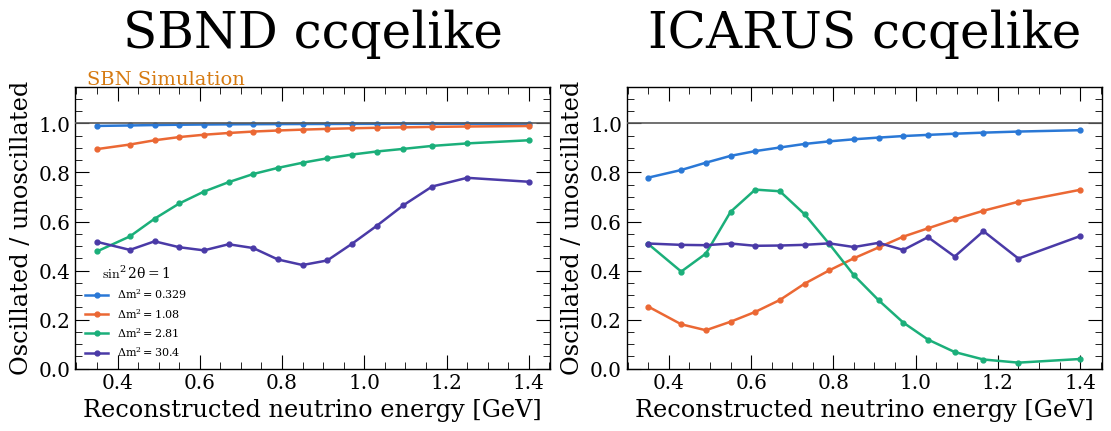

In [7]:
# The same points as a ratio to the unoscillated CV, which is where the shape
# of the disappearance is easiest to read.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, detector in zip(axes, DETECTORS):
    edges, cv = cv_ref[detector, CHANNEL]
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.axhline(1.0, color='0.35', lw=1.2, zorder=3)
    for color, dmsq in zip(SERIES_COLORS, picks):
        ax.plot(centers, spectrum_at(detector, CHANNEL, dmsq, SINSQ) / cv,
                color=color, lw=1.8, marker='o', ms=3.5,
                label=rf'$\Delta m^2 = {dmsq:.3g}$')
    ax.set_xlabel('Reconstructed neutrino energy [GeV]')
    ax.set_ylabel('Oscillated / unoscillated')
    ax.set_title(f'{detector} {CHANNEL}')
    ax.set_ylim(0, 1.15)

axes[0].legend(title=rf'$\sin^2 2\theta = {SINSQ:g}$', frameon=False,
               fontsize=8, loc='lower left')
mark_axis(axes[0], 'SBN Simulation')

## Rate deficit across the whole grid

Total rate lost relative to the unoscillated CV, at every grid point. The band
of strongest disappearance sits at roughly 5-6x higher $\Delta m^2$ for SBND
than for ICARUS, which is just the ratio of their baselines.

SBND    deepest deficit 75.7% at dmsq=9.24, sinsq=1
ICARUS  deepest deficit 76.8% at dmsq=1.74, sinsq=1


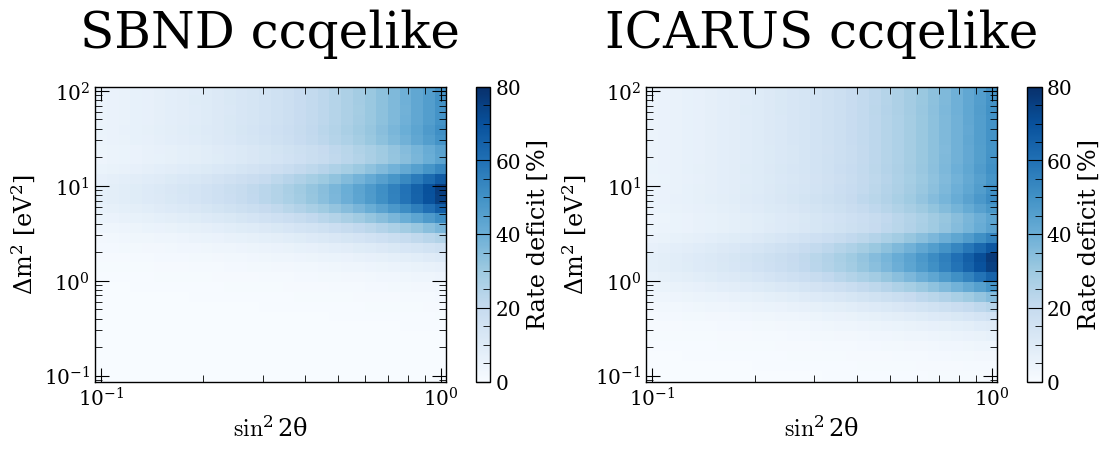

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, detector in zip(axes, DETECTORS):
    table = (pd.DataFrame({'dmsq': scan.dmsq, 'sinsq': scan.sinsq,
                           'deficit': 100 * (1 - osc_rates[detector, CHANNEL])})
             .pivot_table(index='dmsq', columns='sinsq', values='deficit'))
    mesh = ax.pcolormesh(table.columns.to_numpy(), table.index.to_numpy(),
                         table.to_numpy(), shading='nearest',
                         cmap='Blues', vmin=0, vmax=80)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\sin^2 2\theta$')
    ax.set_ylabel(r'$\Delta m^2$ [eV$^2$]')
    ax.set_title(f'{detector} {CHANNEL}')
    fig.colorbar(mesh, ax=ax, label='Rate deficit [%]')

for detector in DETECTORS:
    deepest = int(np.argmin(osc_rates[detector, CHANNEL]))
    print(f'{detector:7s} deepest deficit '
          f'{100 * (1 - osc_rates[detector, CHANNEL][deepest]):.1f}% at '
          f'dmsq={scan.dmsq[deepest]:.3g}, sinsq={scan.sinsq[deepest]:.3g}')

## Bins outside the CV envelope

The comparison itself. `sbnd_scanmatch_v1_PROplot.root` carries the SBND CV and
its systematic band in these same bins and at the same exposure
(`xml/contours/sbnd_scanmatch.xml`, POT 4.196270e+18). For each injected point,
count how many of the 30 SBND bins land outside CV $-\sigma_{low}$ to
CV $+\sigma_{high}$.

The band is asymmetric, so the two sides are read separately rather than
symmetrised.

In [9]:
CV_FILE = INPUT.parent / 'sbnd_scanmatch_v1_PROplot.root'
ENVELOPE_KEY = 'ErrorBand/Var0/nu_SBN_sbnd{channel}_preerrband'

# Bins are concatenated in this order on BOTH sides - the injected spectra and
# the envelope - so column j means the same bin in each.
BAND_ORDER = CHANNELS  # ('ccqelike', 'nproton') -> 16 + 14 = 30 bins


def find_band_key(f, channel):
    """Locate this channel's error band, by name or by search.

    The expected name follows PROfit's mode_detector_channel convention, but
    rather than trust that, fall back to searching ErrorBand/Var0 and report
    what is actually there if the search comes up empty or ambiguous.
    """
    expected = ENVELOPE_KEY.format(channel=channel)
    if expected in f:
        return expected
    available = [k for k in f['ErrorBand/Var0'].keys(cycle=False)
                 if k.endswith('preerrband')]
    matches = [k for k in available if channel in k]
    if len(matches) == 1:
        print(f'note: {expected!r} absent, using {matches[0]!r}')
        return f'ErrorBand/Var0/{matches[0]}'
    raise KeyError(f'no unique band for {channel!r}: matched {matches}. '
                   f'ErrorBand/Var0 holds {available}')


def read_envelope(path):
    """CV, lower and upper systematic errors, concatenated over BAND_ORDER."""
    if not Path(path).exists():
        raise FileNotFoundError(
            f'{path} not found. The caches exist but the plot step has not run:\n'
            '    scripts/profit_run.sh jobs/contours/sbnd_scanmatch.ini plot')
    cv, lo, hi = [], [], []
    with uproot.open(path) as f:
        for channel in BAND_ORDER:
            graph = f[find_band_key(f, channel)]
            cv.append(np.asarray(graph.member('fY')))
            lo.append(np.asarray(graph.member('fEYlow')))
            hi.append(np.asarray(graph.member('fEYhigh')))
    return np.concatenate(cv), np.concatenate(lo), np.concatenate(hi)


cv_band, err_low, err_high = read_envelope(CV_FILE)
scan_cv = np.concatenate([cv_ref['SBND', channel][1] for channel in BAND_ORDER])

# The envelope and the scan must describe the same exposure and the same MC. A
# ~1% difference is the expected MC-version drift; anything larger means the
# two sides are not comparable and the bin counts below would be meaningless.
for channel in BAND_ORDER:
    lo_i = sum(len(cv_ref['SBND', c][1]) for c in BAND_ORDER[:BAND_ORDER.index(channel)])
    hi_i = lo_i + len(cv_ref['SBND', channel][1])
    print(f'{channel:9s} envelope/scan CV = '
          f'{cv_band[lo_i:hi_i].sum() / cv_ref["SBND", channel][1].sum():.4f}')

total_ratio = cv_band.sum() / scan_cv.sum()
print(f'combined  envelope/scan CV = {total_ratio:.4f}')
assert abs(total_ratio - 1) < 0.05, (
    f'envelope and scan disagree on normalisation by {100 * (total_ratio - 1):.1f}%. '
    'Check the SBND POT in xml/contours/sbnd_scanmatch.xml against the scan.')

ccqelike  envelope/scan CV = 1.0059
nproton   envelope/scan CV = 0.9842
combined  envelope/scan CV = 1.0008


In [10]:
# Injected spectra in the same bin order as the envelope.
injected = np.concatenate([osc_spectra['SBND', channel] for channel in BAND_ORDER],
                          axis=1)

band_low = cv_band - err_low
band_high = cv_band + err_high
outside = ((injected < band_low) | (injected > band_high)).sum(axis=1)

print(f'{injected.shape[1]} bins per grid point')
print(f'bins outside: min {outside.min()}, max {outside.max()}, '
      f'mean {outside.mean():.1f}')

30 bins per grid point
bins outside: min 0, max 30, mean 4.5


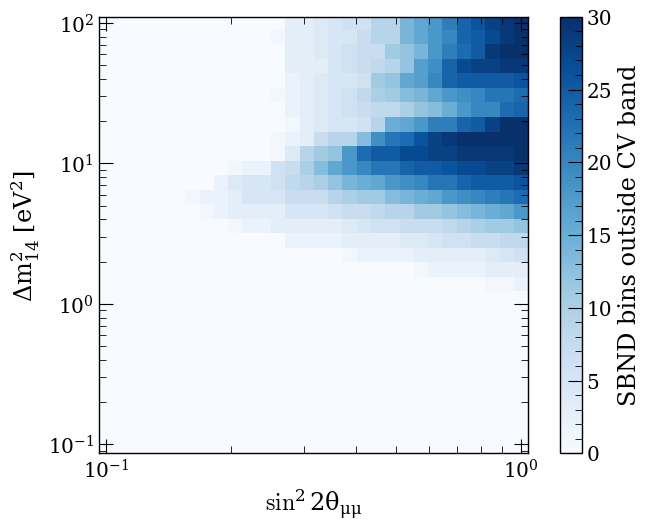

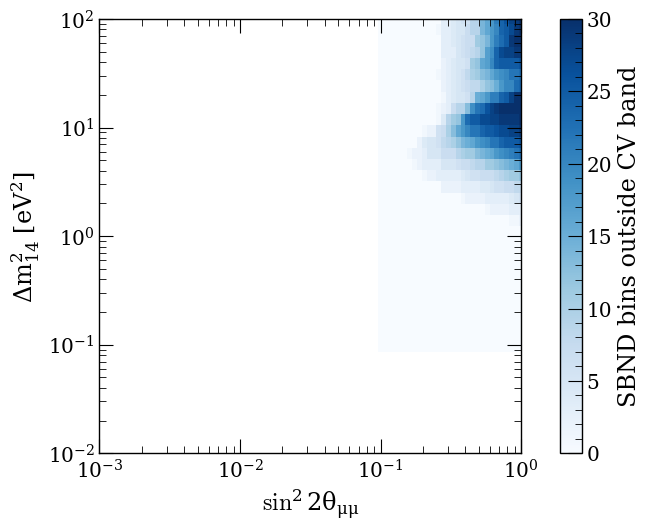

In [17]:
table = (pd.DataFrame({'dmsq': scan.dmsq, 'sinsq': scan.sinsq, 'outside': outside})
         .pivot_table(index='dmsq', columns='sinsq', values='outside'))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
mesh = ax.pcolormesh(table.columns.to_numpy(), table.index.to_numpy(),
                     table.to_numpy(), shading='nearest', cmap='Blues',
                     vmin=0, vmax=injected.shape[1])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\sin^2 2\theta_{\mu\mu}$')
ax.set_ylabel(r'$\Delta m_{14}^2$ [eV$^2$]')
fig.colorbar(mesh, ax=ax, label=f'SBND bins outside CV band')
#mark_axis(ax, 'SBN Simulation')
fig.savefig('/Users/mueller/Projects/spineosc_sbnd_unblinding_request/figures/sbnd_bins_outside_cvband.pdf')

table = (pd.DataFrame({'dmsq': scan.dmsq, 'sinsq': scan.sinsq, 'outside': outside})
         .pivot_table(index='dmsq', columns='sinsq', values='outside'))

# Zoomed out
fig, ax = plt.subplots(figsize=(6.4, 5.2))
mesh = ax.pcolormesh(table.columns.to_numpy(), table.index.to_numpy(),
                     table.to_numpy(), shading='nearest', cmap='Blues',
                     vmin=0, vmax=injected.shape[1])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-3, 1)
ax.set_ylim(1e-2, 1e2)
ax.set_xlabel(r'$\sin^2 2\theta_{\mu\mu}$')
ax.set_ylabel(r'$\Delta m_{14}^2$ [eV$^2$]')
fig.colorbar(mesh, ax=ax, label=f'SBND bins outside CV band')
#mark_axis(ax, 'SBN Simulation')
fig.savefig('/Users/mueller/Projects/spineosc_sbnd_unblinding_request/figures/sbnd_bins_outside_cvband_zoomout.pdf')